# Drift Robustness Checks

Cell-by-cell mirror of `robustness_checks.py`. Three additions for §7.6:

- **#1** Bootstrap CIs (1,000 resamples) and placebo p-values (1,000 sims) on per-trade PnL.
- **#2** Strategy with funding income added to price-reversion PnL.
- **#5** Rolling $\Gamma$: static-2023 vs expanding window vs trailing-365d, plus H1/H2 2024 split.

Each section prints a table; the final cell saves CSVs and the placebo figure.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.home() / "Desktop" / "Classes" / "Smirnov_Research Project" / "defi-perps"
DRIFT_DATA = ROOT / "drift" / "data" / "raw"
ANALYSIS = ROOT / "drift" / "analysis"
MARKETS = ["BTC-PERP", "ETH-PERP", "SOL-PERP"]

SPLIT = pd.Timestamp("2024-01-01", tz="UTC")
MID_2024 = pd.Timestamp("2024-07-01", tz="UTC")

KAPPA_S = 0.00018          # 1.8 bps one-way -> 3.6 bps round-trip
NEUTRAL_BAND = 0.0010      # exit when |ratio - 1| < 10 bps
MAX_HOLD = 48              # forced exit after 48 hours
N_BOOT = 1000
N_PLACEBO = 1000
SEED = 42
Q = 0.99                   # Gamma percentile

rng_global = np.random.default_rng(SEED)

## Load data and compute baseline bounds

In [2]:
frames = []
for m in MARKETS:
    sym = m.split("-")[0]
    fdf = pd.read_parquet(DRIFT_DATA / f"{sym}-PERP_funding_records.parquet")
    fdf["ratio"] = fdf["mark_twap"] / fdf["oracle_twap"]
    frames.append(fdf)
df = pd.concat(frames, ignore_index=True).sort_values(["market", "timestamp"]).reset_index(drop=True)

train = df[df["timestamp"] < SPLIT].copy()
test = df[df["timestamp"] >= SPLIT].copy()

g_static = {
    m: (g["mark_twap"] - g["oracle_twap"]).abs().quantile(Q)
    for m, g in train.groupby("market")
}
print("Static Gamma (99th pct of |M - I_bar| on 2023):")
for m, g in g_static.items():
    print(f"  {m}: {g:.6f} USD")

Static Gamma (99th pct of |M - I_bar| on 2023):
  BTC-PERP: 176.290804 USD
  ETH-PERP: 7.816181 USD
  SOL-PERP: 0.423507 USD


In [3]:
# Per-row L_tk, U_tk under the static Gamma (paper's headline specification)
test_rows = []
for market, grp in test.groupby("market"):
    grp = grp.sort_values("timestamp").reset_index(drop=True).copy()
    gamma_norm = g_static[market] / grp["oracle_twap"]
    funding = grp["f_tk"].abs() * grp["rho_k"]
    grp["L_tk"] = (1 - KAPPA_S) + funding - gamma_norm
    grp["U_tk"] = (1 + KAPPA_S) - funding + gamma_norm
    grp["violation"] = (grp["ratio"] < grp["L_tk"]) | (grp["ratio"] > grp["U_tk"])
    test_rows.append(grp)
test_out = pd.concat(test_rows, ignore_index=True)

test_out.groupby("market")["violation"].agg(["sum", "mean"]).rename(
    columns={"sum": "n_violations", "mean": "viol_rate"}
)

,n_violations,viol_rate
market,,
BTC-PERP,399,0.045475
ETH-PERP,282,0.032144
SOL-PERP,440,0.050154


## Item #2 - Strategy with funding income

For position $= +1$ (long perp / short spot, entered at lower-bound violation), per-hour funding inflow is $-f_{t_k}\,\bar I_{t_k}$ per unit; normalized by entry oracle that is $\approx -f_{t_k}\,\rho_k$. So the funding contribution to the trade's PnL (in ratio units) is

$$\text{pnl\_funding} = -\,\text{position}\;\sum_{t\in[\text{entry},\text{exit})} f_{t_k}\,\rho_k.$$

In [4]:
def simulate_strategy(test_out, kappa_S=KAPPA_S, neutral_band=NEUTRAL_BAND, max_hold=MAX_HOLD):
    out = {}
    for market, grp in test_out.groupby("market"):
        grp = grp.sort_values("timestamp").reset_index(drop=True)
        ratio = grp["ratio"].to_numpy()
        L = grp["L_tk"].to_numpy()
        U = grp["U_tk"].to_numpy()
        f_tk = grp["f_tk"].to_numpy()
        rho = grp["rho_k"].to_numpy()
        n = len(grp)

        position, entry_ratio, entry_idx = 0, None, None
        trades = []
        for i in range(n):
            if position == 0:
                if ratio[i] > U[i]:
                    position, entry_ratio, entry_idx = -1, ratio[i], i
                elif ratio[i] < L[i]:
                    position, entry_ratio, entry_idx = +1, ratio[i], i
            else:
                neutral = abs(ratio[i] - 1.0) < neutral_band
                forced = (i - entry_idx) >= max_hold
                if neutral or forced:
                    pnl_price = position * (ratio[i] - entry_ratio)
                    pnl_fund = -position * float((f_tk[entry_idx:i] * rho[entry_idx:i]).sum())
                    trades.append({
                        "entry_idx": entry_idx, "exit_idx": i,
                        "position": position, "duration": i - entry_idx,
                        "exit_type": "neutral" if neutral else "max_hold",
                        "pnl_price": pnl_price,
                        "pnl_funding": pnl_fund,
                        "pnl_price_net": pnl_price - 2 * kappa_S,
                        "pnl_total_net": pnl_price + pnl_fund - 2 * kappa_S,
                    })
                    position, entry_ratio, entry_idx = 0, None, None
        out[market] = pd.DataFrame(trades)
    return out

trades = simulate_strategy(test_out)
{m: len(t) for m, t in trades.items()}

{'BTC-PERP': 30, 'ETH-PERP': 32, 'SOL-PERP': 43}

In [5]:
rows = []
for m in MARKETS:
    td = trades[m]
    n = len(td)
    rows.append({
        "market": m,
        "n_trades": n,
        "price_only_gross_bps": round(td["pnl_price"].sum() * 1e4, 1),
        "price_only_net_bps": round(td["pnl_price_net"].sum() * 1e4, 1),
        "price_only_winrate_pct": round((td["pnl_price_net"] > 0).mean() * 100, 1),
        "with_funding_gross_bps": round((td["pnl_price"] + td["pnl_funding"]).sum() * 1e4, 1),
        "with_funding_net_bps": round(td["pnl_total_net"].sum() * 1e4, 1),
        "with_funding_winrate_pct": round((td["pnl_total_net"] > 0).mean() * 100, 1),
        "delta_funding_bps": round((td["pnl_total_net"].sum() - td["pnl_price_net"].sum()) * 1e4, 1),
    })
strat_table = pd.DataFrame(rows)
strat_table

,market,n_trades,price_only_gross_bps,price_only_net_bps,price_only_winrate_pct,with_funding_gross_bps,with_funding_net_bps,with_funding_winrate_pct,delta_funding_bps
0,BTC-PERP,30,472.4,364.4,83.3,1456.6,1348.6,100.0,984.2
1,ETH-PERP,32,537.6,422.4,90.6,1143.2,1028.0,100.0,605.6
2,SOL-PERP,43,922.1,767.3,93.0,1968.2,1813.4,100.0,1046.1


## Item #1a - Bootstrap 95% CIs

Resample per-trade PnL with replacement 1,000 times. Report 95% percentile intervals on total PnL, mean per-trade PnL, and Sharpe (mean / std, per-trade).

In [6]:
def bootstrap_stats(pnl, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    pnl = np.asarray(pnl)
    n = len(pnl)
    if n == 0:
        nan = np.array([np.nan, np.nan])
        return {"total_ci": nan, "mean_ci": nan, "sharpe_ci": nan}
    idx = rng.integers(0, n, size=(n_boot, n))
    samples = pnl[idx]
    totals = samples.sum(axis=1)
    means = samples.mean(axis=1)
    stds = samples.std(axis=1, ddof=1)
    sharpes = np.where(stds > 0, means / stds, 0.0)
    return {
        "total_ci": np.percentile(totals, [2.5, 97.5]),
        "mean_ci": np.percentile(means, [2.5, 97.5]),
        "sharpe_ci": np.percentile(sharpes, [2.5, 97.5]),
    }

boot_rows = []
for m in MARKETS:
    td = trades[m]
    pnl = td["pnl_total_net"].to_numpy()
    n = len(pnl)
    actual_total = pnl.sum()
    boot = bootstrap_stats(pnl, n_boot=N_BOOT)
    actual_sharpe = pnl.mean() / pnl.std(ddof=1) if n > 1 and pnl.std(ddof=1) > 0 else np.nan
    boot_rows.append({
        "market": m,
        "n_trades": n,
        "actual_total_bps": round(actual_total * 1e4, 1),
        "boot_total_lo_bps": round(boot["total_ci"][0] * 1e4, 1),
        "boot_total_hi_bps": round(boot["total_ci"][1] * 1e4, 1),
        "actual_mean_bps": round(pnl.mean() * 1e4, 2),
        "boot_mean_lo_bps": round(boot["mean_ci"][0] * 1e4, 2),
        "boot_mean_hi_bps": round(boot["mean_ci"][1] * 1e4, 2),
        "actual_sharpe": round(actual_sharpe, 2),
        "boot_sharpe_lo": round(boot["sharpe_ci"][0], 2),
        "boot_sharpe_hi": round(boot["sharpe_ci"][1], 2),
    })
boot_table = pd.DataFrame(boot_rows)
boot_table

,market,n_trades,actual_total_bps,boot_total_lo_bps,boot_total_hi_bps,actual_mean_bps,boot_mean_lo_bps,boot_mean_hi_bps,actual_sharpe,boot_sharpe_lo,boot_sharpe_hi
0,BTC-PERP,30,1348.6,1107.2,1586.6,44.95,36.91,52.89,1.92,1.55,2.54
1,ETH-PERP,32,1028.0,829.7,1252.9,32.13,25.93,39.15,1.68,1.40,2.26
2,SOL-PERP,43,1813.4,1522.3,2177.1,42.17,35.40,50.63,1.60,1.37,2.11


## Item #1b - Placebo p-values

Each placebo simulation draws $N_\text{actual}$ entry indices uniformly at random from the test settlements (with replacement) and a random direction $\pm 1$. Same exit rule (10 bps neutral band or 48-period max hold). Same 3.6 bps round-trip cost and funding accounting. Report empirical one-sided $p$-value: $\Pr(\text{placebo total} \ge \text{actual total})$.

In [7]:
def placebo_totals(grp, n_trades, n_sims=N_PLACEBO,
                   neutral_band=NEUTRAL_BAND, max_hold=MAX_HOLD,
                   kappa_S=KAPPA_S, seed=SEED):
    rng = np.random.default_rng(seed)
    grp = grp.sort_values("timestamp").reset_index(drop=True)
    ratio = grp["ratio"].to_numpy()
    f_tk = grp["f_tk"].to_numpy()
    rho = grp["rho_k"].to_numpy()
    n = len(grp)
    if n_trades == 0 or n < 2:
        return np.zeros(n_sims)

    out = np.empty(n_sims)
    for s in range(n_sims):
        entries = rng.integers(0, n - 1, size=n_trades)
        dirs = rng.choice([-1, 1], size=n_trades)
        total = 0.0
        for idx, pos in zip(entries, dirs):
            entry_ratio = ratio[idx]
            exit_idx = min(idx + max_hold, n - 1)
            for j in range(idx + 1, min(idx + max_hold + 1, n)):
                if abs(ratio[j] - 1.0) < neutral_band:
                    exit_idx = j
                    break
            pnl_price = pos * (ratio[exit_idx] - entry_ratio)
            pnl_fund = -pos * float((f_tk[idx:exit_idx] * rho[idx:exit_idx]).sum())
            total += pnl_price + pnl_fund - 2 * kappa_S
        out[s] = total
    return out

placebo_arrays = {}
placebo_rows = []
for m in MARKETS:
    td = trades[m]
    pnl = td["pnl_total_net"].to_numpy()
    actual_total = pnl.sum()
    grp = test_out[test_out["market"] == m]
    plac = placebo_totals(grp, n_trades=len(pnl), n_sims=N_PLACEBO)
    placebo_arrays[m] = plac
    p_one = float((plac >= actual_total).mean())
    p_two = float((np.abs(plac) >= abs(actual_total)).mean())
    placebo_rows.append({
        "market": m,
        "actual_total_bps": round(actual_total * 1e4, 1),
        "placebo_mean_bps": round(plac.mean() * 1e4, 1),
        "placebo_sd_bps": round(plac.std(ddof=1) * 1e4, 1),
        "placebo_q025_bps": round(np.percentile(plac, 2.5) * 1e4, 1),
        "placebo_q975_bps": round(np.percentile(plac, 97.5) * 1e4, 1),
        "p_one_sided": p_one,
        "p_two_sided": p_two,
    })
placebo_table = pd.DataFrame(placebo_rows)
placebo_table

,market,actual_total_bps,placebo_mean_bps,placebo_sd_bps,placebo_q025_bps,placebo_q975_bps,p_one_sided,p_two_sided
0,BTC-PERP,1348.6,-109.6,104.1,-322.1,96.8,0.0,0.0
1,ETH-PERP,1028.0,-116.1,79.8,-267.3,39.7,0.0,0.0
2,SOL-PERP,1813.4,-150.4,109.9,-383.4,71.5,0.0,0.0


In [8]:
# Sanity check: placebo mean should be close to -3.6 * n_trades bps (cost drag of N random trades)
for m in MARKETS:
    n = len(trades[m])
    expected_drag = -3.6 * n
    observed = placebo_arrays[m].mean() * 1e4
    print(f"{m}: n={n}, expected drag = {expected_drag:.1f} bps, observed = {observed:.1f} bps")

BTC-PERP: n=30, expected drag = -108.0 bps, observed = -109.6 bps
ETH-PERP: n=32, expected drag = -115.2 bps, observed = -116.1 bps
SOL-PERP: n=43, expected drag = -154.8 bps, observed = -150.4 bps


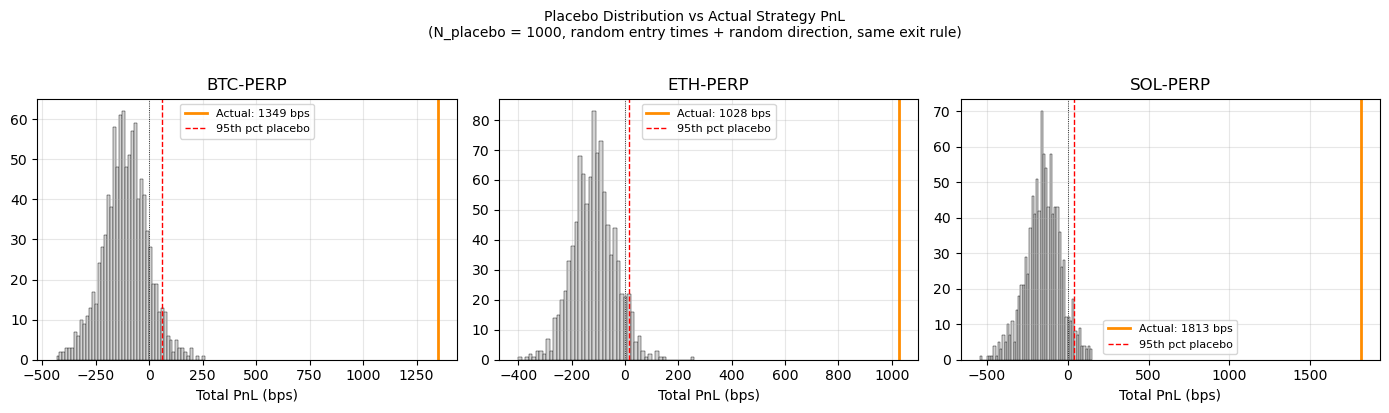

In [9]:
# Placebo histograms (figure6_placebo_distributions.png)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, m in zip(axes, MARKETS):
    actual = trades[m]["pnl_total_net"].sum() * 1e4
    plac = placebo_arrays[m] * 1e4
    ax.hist(plac, bins=50, color="lightgray", edgecolor="black", linewidth=0.3)
    ax.axvline(actual, color="darkorange", linewidth=2, label=f"Actual: {actual:.0f} bps")
    ax.axvline(np.percentile(plac, 95), color="red", linewidth=1, linestyle="--",
               label="95th pct placebo")
    ax.axvline(0, color="black", linewidth=0.6, linestyle=":")
    ax.set_title(m)
    ax.set_xlabel("Total PnL (bps)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle(
    "Placebo Distribution vs Actual Strategy PnL\n"
    f"(N_placebo = {N_PLACEBO}, random entry times + random direction, same exit rule)",
    fontsize=10, y=1.02,
)
plt.tight_layout()
plt.savefig(ANALYSIS / "figure6_placebo_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Item #5 - Rolling $\Gamma$ robustness

Three specifications:

- **static_2023**: $\Gamma$ = 99th pct of $|M-\bar I|$ on 2023 (paper baseline).
- **expanding**: per-row 99th pct over all data with timestamp $< t$.
- **trailing_365d**: per-row 99th pct over $[t-365\text{d}, t)$.

Both rolling specs are shifted by 1 row to be strictly causal.

In [10]:
def gamma_series(df, variant, train_end=SPLIT, q=Q):
    out = []
    for market, grp in df.groupby("market"):
        grp = grp.sort_values("timestamp").reset_index(drop=True).copy()
        ab = (grp["mark_twap"] - grp["oracle_twap"]).abs()
        ab.index = pd.DatetimeIndex(grp["timestamp"])
        if variant == "static_2023":
            grp["gamma"] = float(ab[ab.index < train_end].quantile(q))
        elif variant == "expanding":
            gt = ab.expanding(min_periods=24 * 30).quantile(q).shift(1)
            grp["gamma"] = gt.values
        elif variant == "trailing_365d":
            gt = ab.rolling("365D", min_periods=24 * 30).quantile(q).shift(1)
            grp["gamma"] = gt.values
        else:
            raise ValueError(variant)
        out.append(grp)
    return pd.concat(out, ignore_index=True)

def violation_table(df, gamma_col="gamma", kappa_S=KAPPA_S):
    rows = []
    for market, grp in df.groupby("market"):
        grp = grp.sort_values("timestamp").reset_index(drop=True).copy()
        gamma_norm = grp[gamma_col] / grp["oracle_twap"]
        funding = grp["f_tk"].abs() * grp["rho_k"]
        L = (1 - kappa_S) + funding - gamma_norm
        U = (1 + kappa_S) - funding + gamma_norm
        valid = gamma_norm.notna()
        viol = ((grp["ratio"] < L) | (grp["ratio"] > U)) & valid
        rate = viol[valid].mean() if valid.any() else np.nan
        rows.append({
            "market": market,
            "n_obs": int(valid.sum()),
            "n_viol": int(viol.sum()),
            "viol_rate_pct": rate * 100 if pd.notna(rate) else np.nan,
        })
    return pd.DataFrame(rows)

In [11]:
rolling_rows = []
for variant in ["static_2023", "expanding", "trailing_365d"]:
    full = gamma_series(df, variant=variant)
    full_test = full[full["timestamp"] >= SPLIT]
    tab = violation_table(full_test)
    for _, r in tab.iterrows():
        rolling_rows.append({"variant": variant, **r.to_dict()})
rolling_table = pd.DataFrame(rolling_rows)
rolling_table

,variant,market,n_obs,n_viol,viol_rate_pct
0,static_2023,BTC-PERP,8774,399,4.547527
1,static_2023,ETH-PERP,8773,282,3.214408
2,static_2023,SOL-PERP,8773,440,5.015388
3,expanding,BTC-PERP,8774,157,1.789378
4,expanding,ETH-PERP,8773,163,1.857973
5,expanding,SOL-PERP,8773,164,1.869372
6,trailing_365d,BTC-PERP,8774,126,1.436061
7,trailing_365d,ETH-PERP,8773,151,1.721190
8,trailing_365d,SOL-PERP,8773,122,1.390630


### Within-test stability: H1 vs H2 of 2024 (under static-2023 $\Gamma$)

In [12]:
half_rows = []
for market, grp in test_out.groupby("market"):
    h1 = grp[grp["timestamp"] < MID_2024]
    h2 = grp[grp["timestamp"] >= MID_2024]
    half_rows.append({
        "market": market,
        "h1_n": len(h1),
        "h1_viol": int(h1["violation"].sum()),
        "h1_rate_pct": h1["violation"].mean() * 100,
        "h2_n": len(h2),
        "h2_viol": int(h2["violation"].sum()),
        "h2_rate_pct": h2["violation"].mean() * 100,
    })
half_table = pd.DataFrame(half_rows)
half_table

,market,h1_n,h1_viol,h1_rate_pct,h2_n,h2_viol,h2_rate_pct
0,BTC-PERP,4363,330,7.563603,4411,69,1.564271
1,ETH-PERP,4363,258,5.913362,4410,24,0.544218
2,SOL-PERP,4363,313,7.173963,4410,127,2.879819


## Save CSV outputs

In [13]:
strat_table.to_csv(ANALYSIS / "tab_strategy_results_robust.csv", index=False)
boot_table.to_csv(ANALYSIS / "tab_bootstrap_strategy.csv", index=False)
placebo_table.to_csv(ANALYSIS / "tab_placebo_strategy.csv", index=False)
rolling_table.to_csv(ANALYSIS / "tab_rolling_gamma.csv", index=False)
half_table.to_csv(ANALYSIS / "tab_half_split.csv", index=False)
print("Saved 5 CSVs to drift/analysis/.")

Saved 5 CSVs to drift/analysis/.
